In [1]:
import cmdstanpy as csp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import *

c:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df, max_day = get_data()

In [3]:
from cmdstanpy import install_cmdstan

install_cmdstan(dir="C:/cmdstan", overwrite=True, compiler=True, cores=8)

14:24:24 - cmdstanpy - INFO - Add C++ toolchain to $PATH: C:\cmdstan\RTools40


CmdStan install directory: C:/cmdstan
Installing CmdStan version: 2.37.0
Download successful, file: C:\Users\sebas\AppData\Local\Temp\tmpmk449hed
Extracting distribution
Unpacked download as cmdstan-2.37.0
Building version cmdstan-2.37.0, may take several minutes, depending on your system.
Overwrite requested, remove existing build of version cmdstan-2.37.0
Rebuilding version cmdstan-2.37.0
Installed cmdstan-2.37.0
Test model compilation


True

In [4]:
model = csp.CmdStanModel(stan_file="..\models\quadratic_trend.stan", force_compile=True)

14:28:09 - cmdstanpy - INFO - compiling stan file C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\models\quadratic_trend.stan to exe file C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\models\quadratic_trend.exe
14:28:25 - cmdstanpy - INFO - compiled model executable: C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\models\quadratic_trend.exe


In [5]:
seasonality = [7, 365.25]
seasonality = [2 * np.pi / (s * max_day) for s in seasonality]

In [6]:
stan_data = {
    "n": len(df),
    "t": df["day"],
    "y": df["no2"],
    "k": 2,
    "omega": np.array(seasonality)
}

In [7]:
fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42
)

14:28:25 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   0%|          | 1/2000 [00:00<06:08,  5.42it/s, (Warmup)]




chain 1:   5%|▌         | 100/2000 [00:11<03:43,  8.50it/s, (Warmup)]





chain 1:  10%|█         | 200/2000 [03:20<34:42,  1.16s/it, (Warmup)]




chain 1:  15%|█▌        | 300/2000 [05:31<34:51,  1.23s/it, (Warmup)]


chain 1:  20%|██        | 400/2000 [06:47<27:49,  1.04s/it, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [07:58<23:04,  1.08it/s, (Warmup)]





chain 1:  30%|███       | 600/2000 [09:11<20:02,  1.16it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [10:11<16:43,  1.30it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [11:08<14:10,  1.41it/s, (Warmup)]



chain 1:  45%|████▌     | 900/2000 [12:00<11:53,  1.54it/s, (Warmup)]






chain 1:  50%|█████     | 1001/2000 [13:08<10:57,  1.52it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [14:06<09:27,  1.59it/s, (Sampling)]

c


14:55:22 - cmdstanpy - INFO - CmdStan done processing.


In [8]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

idata = az.from_cmdstanpy(fit)

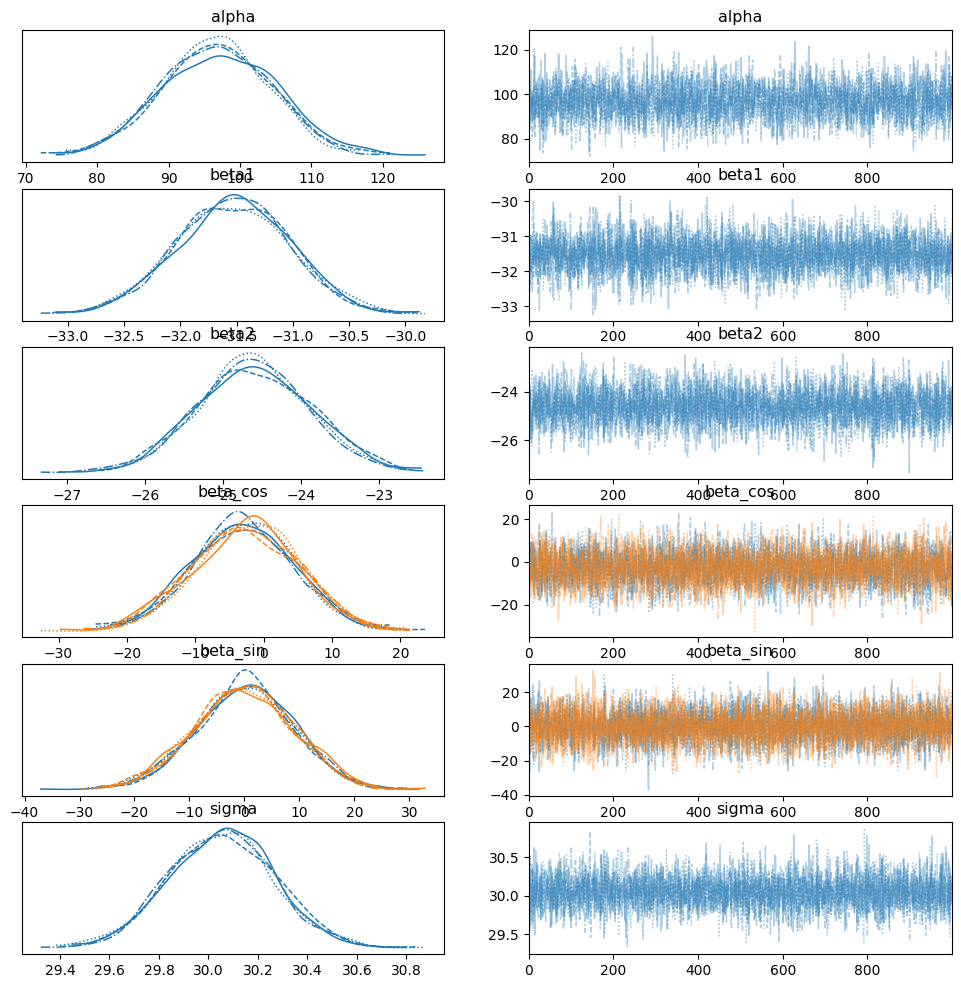

              mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha        96.82  7.78   81.57   110.55       0.15     0.12   2656.79   
beta1       -31.53  0.51  -32.52   -30.61       0.01     0.01   3641.18   
beta2       -24.60  0.72  -25.94   -23.24       0.01     0.01   3840.44   
beta_cos[0]  -2.95  7.47  -16.06    12.09       0.14     0.12   2801.03   
beta_cos[1]  -2.60  7.67  -17.53    10.96       0.16     0.11   2362.86   
beta_sin[0]   0.08  8.90  -17.08    16.35       0.14     0.15   3933.70   
beta_sin[1]  -0.16  8.96  -16.35    16.82       0.13     0.14   4600.92   
sigma        30.05  0.21   29.65    30.44       0.00     0.00   4423.41   

             ess_tail  r_hat  
alpha         2482.02    1.0  
beta1         2819.83    1.0  
beta2         2774.32    1.0  
beta_cos[0]   2371.25    1.0  
beta_cos[1]   2694.62    1.0  
beta_sin[0]   2565.35    1.0  
beta_sin[1]   3307.53    1.0  
sigma         3234.74    1.0  


In [11]:
# 4. Sampling diagnostics
az.plot_trace(idata)
plt.show()

print(az.summary(idata, round_to=2))

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# posterior parameters
alpha = fit.stan_variable("alpha")      # shape: (chains*draws,)
beta1 = fit.stan_variable("beta1")
beta2 = fit.stan_variable("beta2")
beta_cos = fit.stan_variable("beta_cos")  # shape: (chains*draws, k)
beta_sin = fit.stan_variable("beta_sin")
sigma = fit.stan_variable("sigma")

t_vals = stan_data["t"].values  # min-max scaled time
n = len(t_vals)
k = stan_data["k"]
num_draws = alpha.shape[0]


In [16]:
# mu_draws: shape (num_draws, n)
mu_draws = alpha[:, None] + beta1[:, None]*t_vals + beta2[:, None]*t_vals**2

for j in range(k):
    mu_draws += beta_cos[:, j][:, None] * np.cos(stan_data["omega"][j]*t_vals)
    mu_draws += beta_sin[:, j][:, None] * np.sin(stan_data["omega"][j]*t_vals)


In [17]:
y_pred_draws = mu_draws + np.random.normal(0, sigma[:, None], size=mu_draws.shape)


In [18]:
mu_mean = mu_draws.mean(axis=0)
mu_low, mu_high = np.percentile(mu_draws, [2.5, 97.5], axis=0)
y_low, y_high = np.percentile(y_pred_draws, [2.5, 97.5], axis=0)


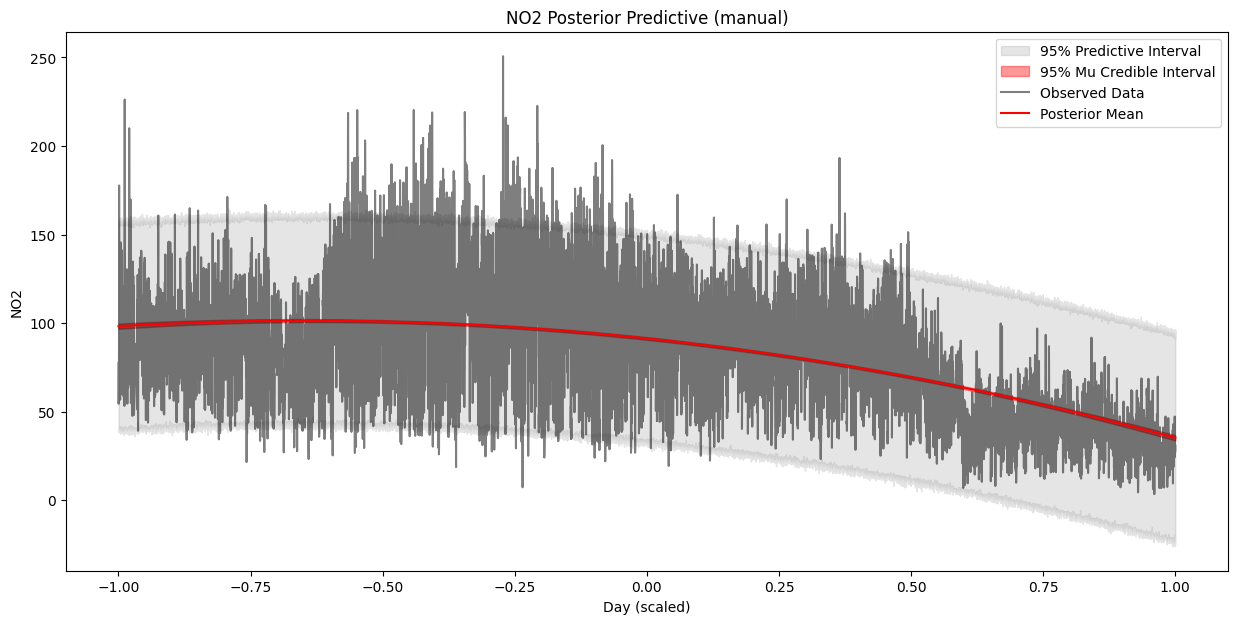

In [19]:
y_vals = stan_data["y"]

plt.figure(figsize=(15,7))
plt.fill_between(t_vals, y_low, y_high, color="gray", alpha=0.2, label="95% Predictive Interval")
plt.fill_between(t_vals, mu_low, mu_high, color="red", alpha=0.4, label="95% Mu Credible Interval")
plt.plot(t_vals, y_vals, color="black", alpha=0.5, label="Observed Data")
plt.plot(t_vals, mu_mean, color="red", lw=1.5, label="Posterior Mean")
plt.xlabel("Day (scaled)")
plt.ylabel("NO2")
plt.title("NO2 Posterior Predictive (manual)")
plt.legend()
plt.show()


LOOIC

         Estimate     SE
elpd_loo -49983.1   89.9
p_loo      3951.3 3948.1
looic     99966.3  179.8
------
MCSE of elpd_loo is NA.
MCSE and ESS estimates assume independent draws (r_eff=1).

Pareto k diagnostic values:
                         Count Pct.    Min. ESS
(-Inf, 0.7]   (good)     10373 100.0%  3876    
   (0.7, 1]   (bad)          0   0.0%  <NA>
   (1, Inf)   (very bad)     1   0.0%  <NA>
See help('pareto-k-diagnostic') for details.

In [55]:
import numpy as np
import arviz as az
idata = az.from_cmdstanpy(fit)

# posterior draws from idata
# Stack over chains/draws
# Convert posterior to numpy with draw dimension first
beta_cos = idata.posterior["beta_cos"].values  # shape: (chains, draws, k)
beta_sin = idata.posterior["beta_sin"].values  # shape: (chains, draws, k)

# Reshape into (num_draws, k)
n_chains, n_draws, k = beta_cos.shape
beta_cos = beta_cos.reshape(n_chains * n_draws, k)
beta_sin = beta_sin.reshape(n_chains * n_draws, k)

# Same for scalars
alpha = idata.posterior["alpha"].values.reshape(-1)
beta1 = idata.posterior["beta1"].values.reshape(-1)
beta2 = idata.posterior["beta2"].values.reshape(-1)
sigma = idata.posterior["sigma"].values.reshape(-1)

t_vals = stan_data["t"].values  # scaled time
y_vals = stan_data["y"].values
omega = stan_data["omega"]
k = stan_data["k"]


In [56]:
draw_idx = np.random.choice(alpha.shape[0], size=200, replace=False)

alpha_s = alpha[draw_idx]
beta1_s = beta1[draw_idx]
beta2_s = beta2[draw_idx]
beta_cos_s = beta_cos[draw_idx, :]
beta_sin_s = beta_sin[draw_idx, :]
sigma_s = sigma[draw_idx]


In [58]:
n = len(y_vals)
mu = alpha[:, None] + beta1[:, None]*t_vals + beta2[:, None]*t_vals**2

for j in range(k):
    mu += beta_cos[:, j][:, None] * np.cos(omega[j] * t_vals)
    mu += beta_sin[:, j][:, None] * np.sin(omega[j] * t_vals)

# log-likelihood: shape (num_draws, n)
log_lik = -0.5*np.log(2*np.pi*sigma[:, None]**2) - 0.5*((y_vals - mu)/sigma[:, None])**2


In [64]:
df_loglik = pd.DataFrame(log_lik)
df_loglik.to_csv("log_lik_quad.csv")

In [61]:
len(log_lik)
log_lik = np.random.choice(log_lik)

4000

In [59]:
idata.add_groups(log_likelihood={"y": log_lik})


In [66]:
idata = az.from_cmdstanpy(fit)
idata.to_netcdf("no2_quad.nc")


'no2_quad.nc'

In [69]:
idata

Inference data with groups:
	> posterior
	> sample_stats

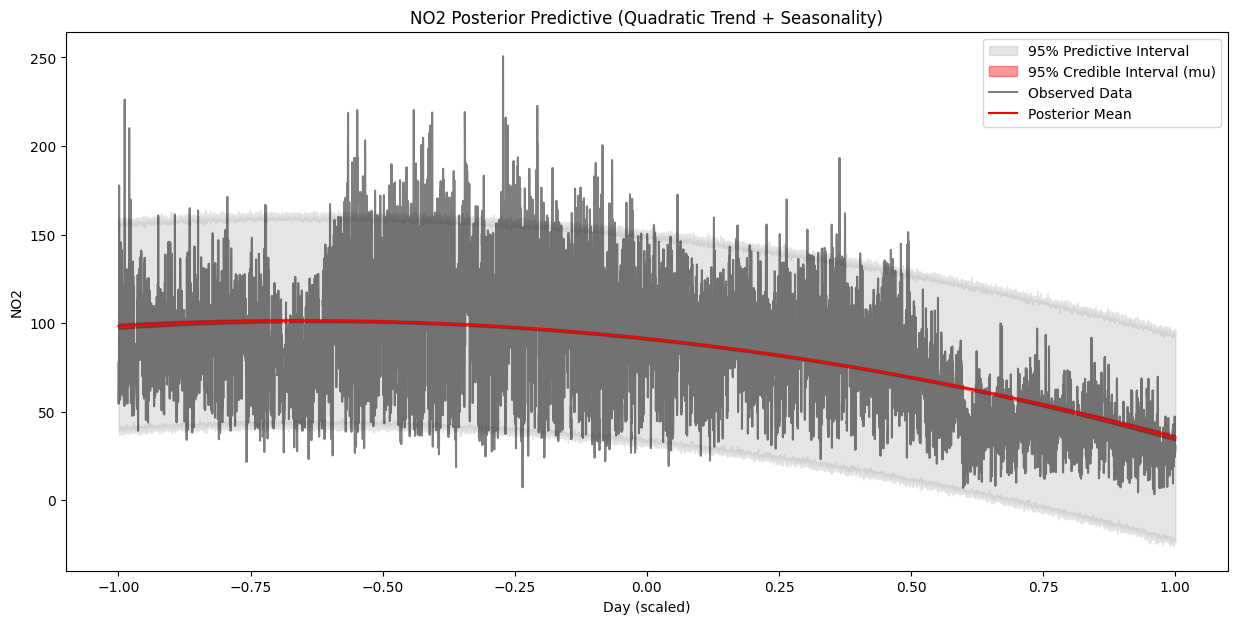

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Extract posterior draws from idata
alpha = idata_quad.posterior["alpha"].values.reshape(-1)        # (n_draws,)
beta1 = idata_quad.posterior["beta1"].values.reshape(-1)
beta2 = idata_quad.posterior["beta2"].values.reshape(-1)
beta_cos = idata_quad.posterior["beta_cos"].values.reshape(-1, idata_quad.posterior["beta_cos"].shape[-1])
beta_sin = idata_quad.posterior["beta_sin"].values.reshape(-1, idata_quad.posterior["beta_sin"].shape[-1])
sigma = idata_quad.posterior["sigma"].values.reshape(-1)

t_vals = df["day"].values         # (n_obs,)
y_vals = df["no2"].values
n_draws = alpha.shape[0]
n_obs = t_vals.shape[0]
k = beta_cos.shape[1]             # number of seasonal frequencies

# 1. Quadratic trend
mu_draws = alpha[:, None] + beta1[:, None]*t_vals[None, :] + beta2[:, None]*t_vals[None, :]**2  # (n_draws, n_obs)

# 2. Add seasonal harmonics
for j in range(k):
    mu_draws += beta_cos[:, j][:, None] * np.cos(omega[j] * t_vals)[None, :]
    mu_draws += beta_sin[:, j][:, None] * np.sin(omega[j] * t_vals)[None, :]

# 3. Add observation noise for posterior predictive
y_pred_draws = mu_draws + np.random.normal(0, sigma[:, None], size=mu_draws.shape)

# 4. Summaries
mu_mean = mu_draws.mean(axis=0)
mu_low, mu_high = np.percentile(mu_draws, [2.5, 97.5], axis=0)
y_low, y_high = np.percentile(y_pred_draws, [2.5, 97.5], axis=0)

# 5. Save posterior predictive draws
np.save("posterior_pred_quad.npy", y_pred_draws)

# 6. Plot
plt.figure(figsize=(15,7))
plt.fill_between(t_vals, y_low, y_high, color="gray", alpha=0.2, label="95% Predictive Interval")
plt.fill_between(t_vals, mu_low, mu_high, color="red", alpha=0.4, label="95% Credible Interval (mu)")
plt.plot(t_vals, y_vals, color="black", alpha=0.5, label="Observed Data")
plt.plot(t_vals, mu_mean, color="red", lw=1.5, label="Posterior Mean")
plt.xlabel("Day (scaled)")
plt.ylabel("NO2")
plt.title("NO2 Posterior Predictive (Quadratic Trend + Seasonality)")
plt.legend()
plt.show()
